In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import warnings
import pickle as pkl
import sccoda

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import tensorflow as tf
tf.random.set_seed(1)  # setting the same seed makes multiple runs of scCODA exactly reproducible

warnings.filterwarnings("ignore")

basedir = "/Users/apatel2/Documents/github/HTAPP_neuroblastoma/output/Fig2/"

#resolution = "fine"  # use fine or coarse resolution to define cell types
resolution = "coarse"
countsfile = f"{basedir}cell_counts.csv"
#"cleaned" file has erythrocytes and zona glomerulosa cell counts removed

model_specs = [("Treatment_Status", "C(Treatment_Status, Treatment('untreated'))"),
               ("Treatment_Status", "C(Treatment_Status, Treatment('treated_chemotherapy'))"),
               ("Treatment_Status", "C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))")]

In [2]:
# Read counts file into scCODA
cell_counts = pd.read_csv(countsfile, skip_blank_lines = True)
#sampletracking.dropna(axis=0, how='all', inplace = True)
cell_counts = cell_counts.drop(columns=['Unnamed: 0'])

first_covariate_index = cell_counts.columns.tolist().index('orig.ident')
cell_counts.columns[first_covariate_index:]

# Subset counts data to only look at nucleus samples
# cell_counts = cell_counts[cell_counts['condition'] == "nucleus"]
cell_counts.head()

data_nb = dat.from_pandas(cell_counts, covariate_columns=cell_counts.columns[first_covariate_index:])
print(data_nb.X)
print(data_nb.obs)

#remove "unknown" treatment status groups and narrow to high risk
data_nb = data_nb[data_nb.obs["COG_Risk"].isin(["High"])]
data_nb = data_nb[data_nb.obs["Treatment_Status"].isin(["untreated", "treated_chemotherapy", "treated_chemo-immunotherapy"])]

print(data_nb.obs)

[[  850  2743  1666   959]
 [  328   616  6930   287]
 [  655  2159  3918   818]
 [  320   683  7578   198]
 [ 1858   852  2706  2788]
 [  112   343  6414   233]
 [ 5992   655  1138  8901]
 [  167  1698  5172   212]
 [    0    88  7339    18]
 [ 1038  4011  6991  1921]
 [  338   168  7320   582]
 [    0    90  6008   183]
 [  428  1542  9358  1123]
 [ 1345  1170  2949  4860]
 [  262   637  6950   117]
 [  480     0  6516     0]
 [ 1671  1190   281   567]
 [   75   197  2508     0]
 [  673  8651 13434   417]
 [  525   617  7531   293]
 [  325   210  6804  1054]
 [  117   524  4904   122]
 [    0     0  5595   114]
 [  316  1369  5340   287]
 [  270  1502  4886   324]
 [  150   766 11224   518]
 [  597   635  3098   675]
 [  244  1116 25555   662]
 [    0    78  4995     0]
 [  203   817  1999   533]
 [ 1018   376  3447  4855]
 [ 1931  3159  5697  6455]
 [    0   895 10916  2714]
 [ 2243   227   942  3448]
 [  106  1253  4318   314]
 [  649  2467 13570   534]
 [  303   878 25173   133]
 

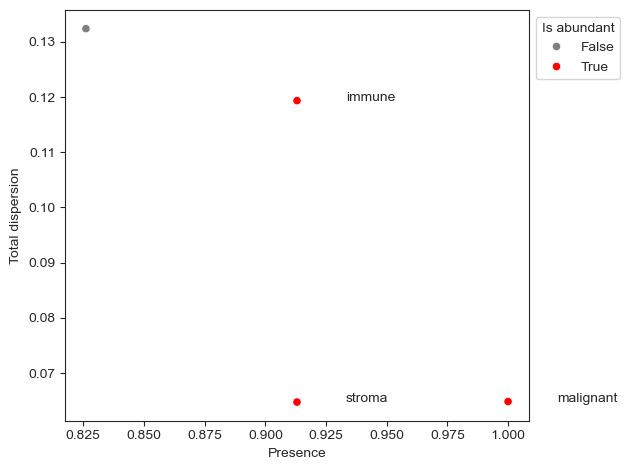

In [3]:
viz.rel_abundance_dispersion_plot(
    data=data_nb,
    abundant_threshold=0.9
)
plt.show()

feature: Treatment_Status
formula: C(Treatment_Status, Treatment('untreated'))
Reference: endothelium


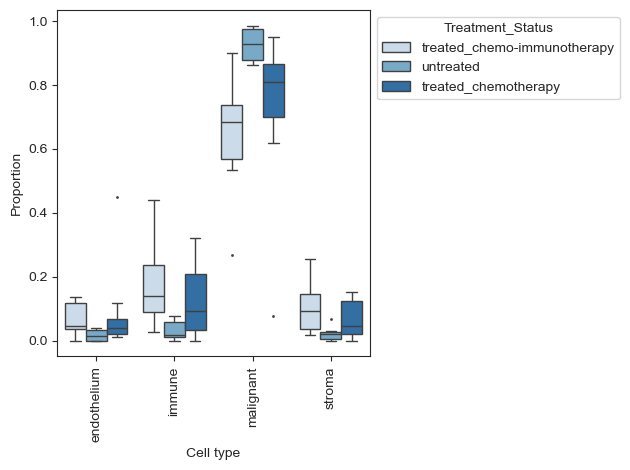

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:27<00:00, 716.08it/s]


MCMC sampling finished. (35.836 sec)
Acceptance rate: 57.6%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -1.025       343.746313
immune                -0.737       458.474155
malignant              1.918      6521.788467
stroma                -0.898       390.295413


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma                   0.0   
C(Trea

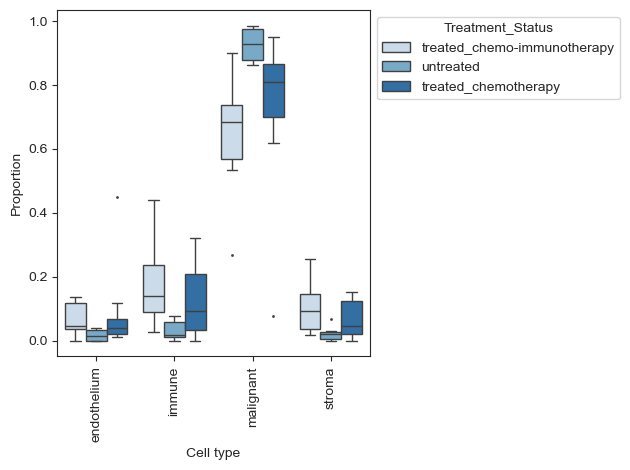

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 708.74it/s]


MCMC sampling finished. (36.160 sec)
Acceptance rate: 45.2%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.974       285.645684
immune                -0.427       493.613180
malignant              2.161      6566.604605
stroma                -0.719       368.614792


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma                   0.0   
C(Trea

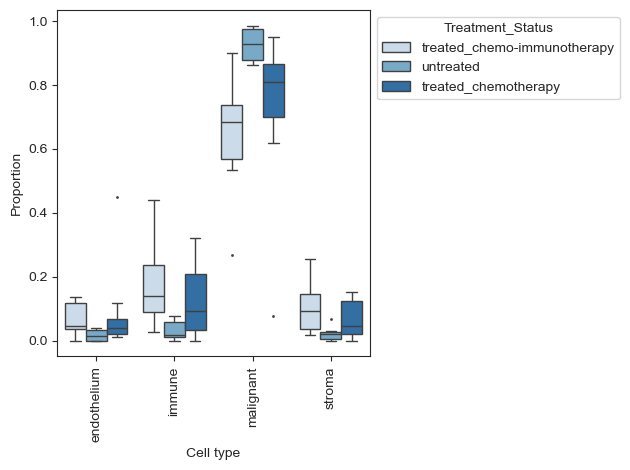

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 712.01it/s]


MCMC sampling finished. (35.803 sec)
Acceptance rate: 50.7%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -1.064       525.912642
immune                -0.681       771.344518
malignant              1.330      5762.548594
stroma                -0.845       654.672506


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma                   0.0   
C(Trea

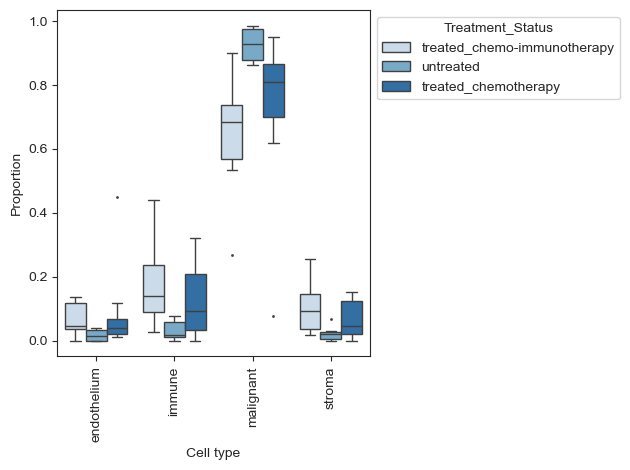

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 710.39it/s]


MCMC sampling finished. (36.027 sec)
Acceptance rate: 56.8%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('untreated'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -1.003       295.295359
immune                -0.557       461.266548
malignant              2.096      6548.400314
stroma                -0.676       409.516040


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('untreated'))[T.t... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma                   0.0   
C(Trea

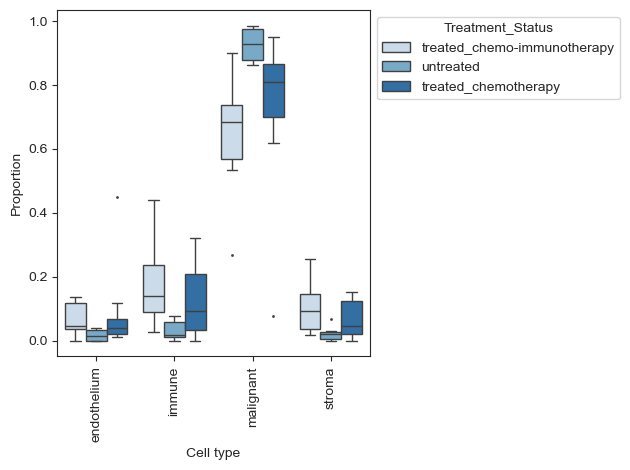

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 708.35it/s]


MCMC sampling finished. (35.951 sec)
Acceptance rate: 51.9%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.799       694.165842
immune                -0.388      1047.027941
malignant              1.210      5175.601780
stroma                -0.660       797.682698


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              0.00000

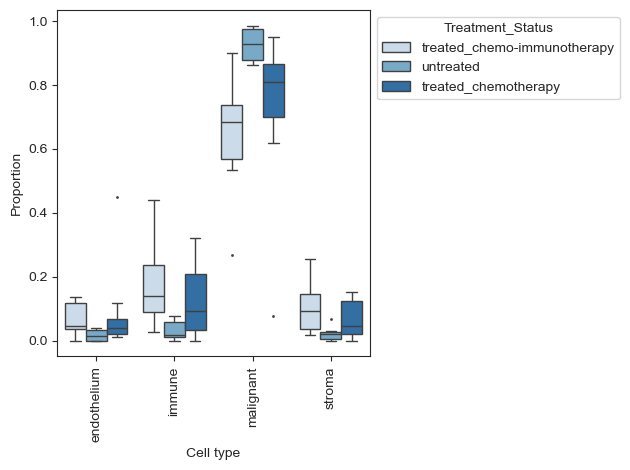

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 705.38it/s]


MCMC sampling finished. (36.135 sec)
Acceptance rate: 52.8%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.708       746.357513
immune                -0.348      1069.776177
malignant              1.214      5101.065535
stroma                -0.642       797.279036


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              0.00000

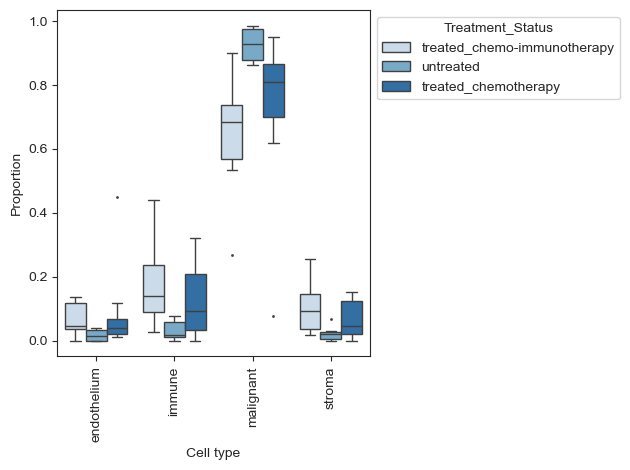

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 709.21it/s]


MCMC sampling finished. (35.944 sec)
Acceptance rate: 46.6%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.718       680.586081
immune                -0.484       860.018852
malignant              1.376      5524.534725
stroma                -0.765       649.338603


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma                   0.

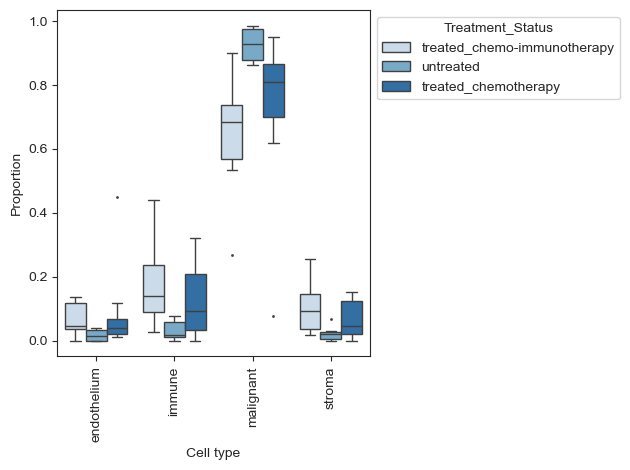

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 711.10it/s]


MCMC sampling finished. (35.809 sec)
Acceptance rate: 62.6%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('treated_chemotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.714       735.526681
immune                -0.389      1017.991467
malignant              1.231      5144.002825
stroma                -0.609       816.957288


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemothe... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              0.00000

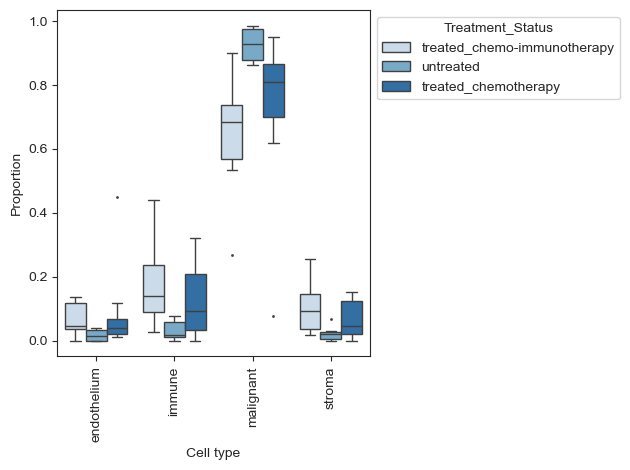

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 707.57it/s]


MCMC sampling finished. (35.955 sec)
Acceptance rate: 55.0%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 0
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.797       685.051829
immune                -0.282      1146.529116
malignant              1.195      5021.552852
stroma                -0.568       861.344463


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              

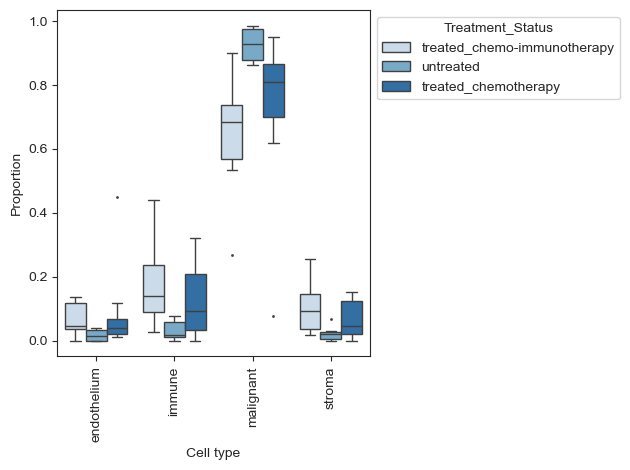

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 708.93it/s]


MCMC sampling finished. (35.938 sec)
Acceptance rate: 52.4%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 1
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.739       721.187235
immune                -0.349      1065.179695
malignant              1.211      5068.999764
stroma                -0.564       859.111566


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              

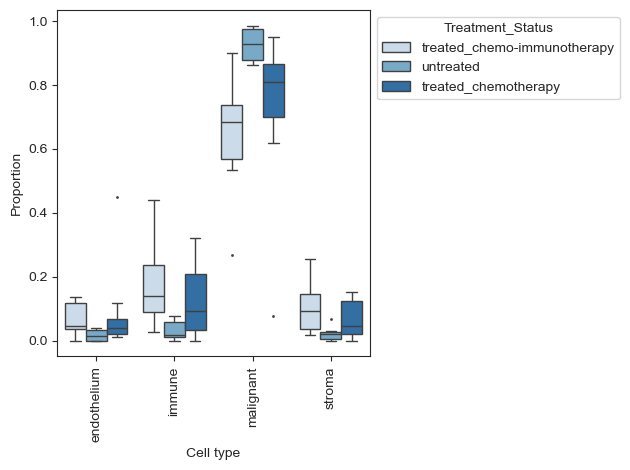

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 712.12it/s]


MCMC sampling finished. (35.776 sec)
Acceptance rate: 51.3%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 2
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.747       647.049943
immune                -0.278      1034.241393
malignant              1.357      5305.097786
stroma                -0.629       728.089138


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... endothelium              0.0  \
                                                   immune                   0.0   
                                                   malignant                0.0   
                                                   stroma              

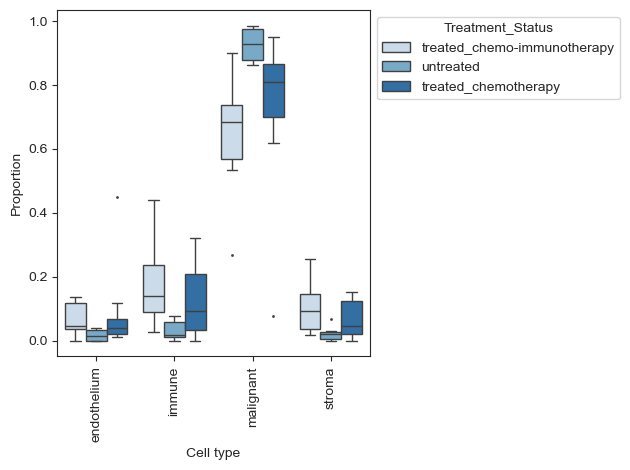

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|████████████████████████████████████| 20000/20000 [00:28<00:00, 710.70it/s]


MCMC sampling finished. (35.844 sec)
Acceptance rate: 55.3%
Compositional Analysis summary:

Data: 23 samples, 4 cell types
Reference index: 3
Formula: C(Treatment_Status, Treatment('treated_chemo-immunotherapy'))

Intercepts:
             Final Parameter  Expected Sample
Cell Type                                    
endothelium           -0.751       710.027669
immune                -0.274      1144.020327
malignant              1.212      5055.863510
stroma                -0.626       804.566755


Effects:
                                                                Final Parameter   
Covariate                                          Cell Type                      
C(Treatment_Status, Treatment('treated_chemo-im... endothelium         0.000000  \
                                                   immune              0.000000   
                                                   malignant           0.000000   
                                                   stroma              

In [5]:
tf.random.set_seed(1)

i = 0
feature = model_specs[i][0]
formula = model_specs[i][1]

cell_types = data_nb.var.index

for feature, formula in model_specs:
    #results_cycle = pd.DataFrame(index=cell_types, columns=["times_credible"]).fillna(0)
    for ct in cell_types:
        print(f"feature: {feature}")
        print(f"formula: {formula}")
        print(f"Reference: {ct}")

        viz.boxplots(data_nb, feature_name=feature, plot_facets=False, y_scale="relative", add_dots=False)
        plt.savefig(f"{basedir}/{feature}.pdf", bbox_inches="tight")
        plt.show()
        
        # Run inference
        model_temp = mod.CompositionalAnalysis(data_nb, formula=formula, reference_cell_type=ct)
        temp_results = model_temp.sample_hmc()
        temp_results.summary()
        print(temp_results.credible_effects())
                     
        # Select credible effects
        #cred_eff = temp_results.credible_effects()
        #cred_eff.index = cred_eff.index.droplevel(level=0)
        
        # add up credible effects'
        #results_cycle["times_credible"] += cred_eff.astype("int")
        
    #results_cycle["pct_credible"] = results_cycle["times_credible"]/len(cell_types)
    #results_cycle["is_credible"] = results_cycle["pct_credible"] > 0.5
    #print(results_cycle)